# Project 14 — Tadpoles (hierarchical Binomial, shrinkage)

**Tier 3 · Hierarchical** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P14_tadpoles-hierarchical/P14_tadpoles-hierarchical_12-06-2026_Opus48.ipynb)

The first **multilevel** model: 48 tanks of reed-frog tadpoles, each with its own survival probability,
tied together by an adaptive prior. New skills: **partial pooling / shrinkage** (small tanks borrow
strength from the grand mean), a **non-centered** parameterization, and **Simulation-Based
Calibration (SBC)** to prove the sampler is calibrated.

## Learning objectives
1. Build a hierarchical Binomial GLM with a varying intercept per tank: `logit(p) = a_tank[tank]`.
2. Visualize **shrinkage** — raw per-tank survival vs partial-pooled posterior; show small tanks shrink most.
3. Use a **non-centered** parameterization (`a = a_bar + z·sigma`) for an efficient funnel-free geometry.
4. Run **SBC** on `sigma_tank` to confirm calibration (Talts et al. 2018).
5. Compare hierarchical vs complete-pooling with **PSIS-LOO**.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
trapz = getattr(np, "trapezoid", None) or np.trapz
RANDOM_SEED = 14
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate 48 tanks from known `a_bar = 1.4`, `sigma_tank = 1.0` (non-centered), fit, confirm recovery.

In [2]:
abar_t, sig_t = 1.4, 1.0
n_tank = 48; dens_sim = rng.choice([10,25,35], n_tank)
a_true = rng.normal(abar_t, sig_t, n_tank)
surv_sim = rng.binomial(dens_sim, 1/(1+np.exp(-a_true)))
with pm.Model() as m0:
    a_bar = pm.Normal("a_bar", 0, 1.5)
    sigma = pm.Exponential("sigma", 1.0)
    z = pm.Normal("z", 0, 1, shape=n_tank)
    a = pm.Deterministic("a", a_bar + z*sigma)
    pm.Binomial("surv", n=dens_sim, logit_p=a, observed=surv_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.95,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, var_names=["a_bar","sigma"], hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for name,tr in [("a_bar",abar_t),("sigma",sig_t)]:
    print(name, "recovered:", bool(s0.loc[name,"hdi_5%"] <= tr <= s0.loc[name,"hdi_95%"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a_bar, sigma, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


        mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a_bar  1.500   1.268    1.738    1.0    1621.0
sigma  0.778   0.561    1.008    1.0    1635.0
a_bar recovered: True
sigma recovered: True


## Data load — reedfrogs (`;`-delimited), 48 tanks

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/reedfrogs.csv"
CACHE = "data/reedfrogs.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
df["tank"] = np.arange(len(df))
print("tanks:", df.shape)
df.head()

loaded from raw URL
tanks: (48, 6)


,density,pred,size,surv,propsurv,tank
0,10,no,big,9,0.9,0
1,10,no,big,10,1.0,1
2,10,no,big,7,0.7,2
3,10,no,big,10,1.0,3
4,10,no,small,9,0.9,4


## Stage 1–2 — Question & EDA
**Question:** what is each tank's survival probability, and how much do tanks vary? **Target:** the
across-tank sd `sigma_tank` and per-tank survival. Tanks differ in **density** (10/25/35), so small
tanks give noisier raw proportions — exactly where pooling helps.

n tanks 48 | densities [np.int64(10), np.int64(25), np.int64(35)] | overall survival 0.699


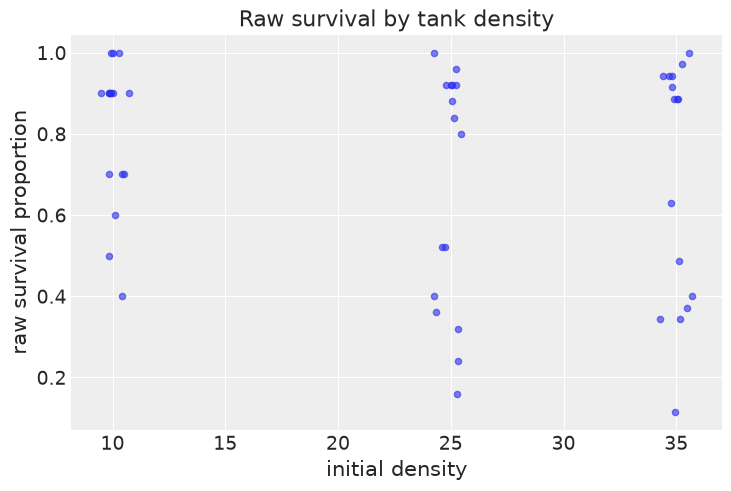

In [4]:
dens = df.density.values; surv = df.surv.values; tank = df.tank.values
propsurv = surv/dens
print(f"n tanks {len(df)} | densities {sorted(set(dens))} | overall survival {surv.sum()/dens.sum():.3f}")
plt.scatter(dens + rng.normal(0,0.4,len(df)), propsurv, s=20, alpha=.6)
plt.xlabel("initial density"); plt.ylabel("raw survival proportion")
plt.title("Raw survival by tank density"); plt.show()

## Stage 3 — Model specification (hierarchical, non-centered)
$$\text{surv}_i \sim \mathrm{Binomial}(\text{density}_i, p_i),\quad \mathrm{logit}(p_i) = a_{\text{tank}[i]},$$
$$a_{\text{tank}} = \bar a + z\,\sigma_{\text{tank}},\quad z \sim \mathrm{Normal}(0,1),\quad \bar a \sim \mathrm{Normal}(0,1.5),\quad \sigma_{\text{tank}} \sim \mathrm{Exponential}(1).$$
The **non-centered** form (`a = a_bar + z·sigma`) decouples the per-tank offsets from `sigma_tank`,
removing the funnel that plagues the centered version when `sigma_tank` is small.

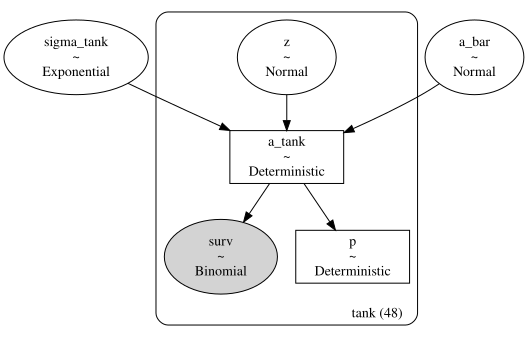

In [5]:
coords = {"tank": df.tank.values}
with pm.Model(coords=coords) as model:
    a_bar = pm.Normal("a_bar", 0, 1.5)
    sigma_tank = pm.Exponential("sigma_tank", 1.0)
    z = pm.Normal("z", 0, 1, dims="tank")
    a_tank = pm.Deterministic("a_tank", a_bar + z*sigma_tank, dims="tank")
    p = pm.Deterministic("p", pm.math.invlogit(a_tank), dims="tank")
    pm.Binomial("surv", n=dens, logit_p=a_tank, observed=surv, dims="tank")
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| a_bar,sigma_tank,z -> a_tank -> surv")

## Stage 4 — Prior predictive on the OUTCOME scale (survival probabilities)
Push the prior through the inverse-logit to confirm it spreads survival probabilities across (0,1)
without piling at the 0/1 edges.

Sampling: [a_bar, sigma_tank, surv, z]


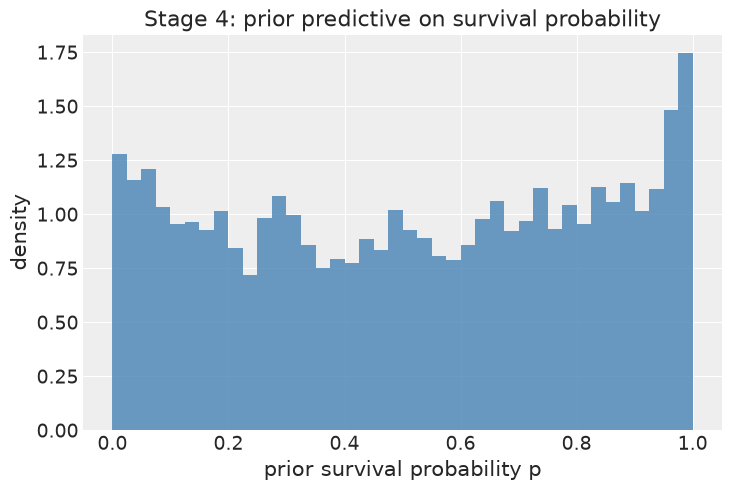

prior p: median 0.52 | frac<0.02 0.03 | frac>0.98 0.03


In [6]:
with model:
    pp = pm.sample_prior_predictive(samples=400, random_seed=RANDOM_SEED)
p_prior = 1/(1+np.exp(-pp.prior["a_tank"].values.ravel()))
plt.hist(p_prior, bins=40, density=True, color="steelblue", alpha=.8)
plt.xlabel("prior survival probability p"); plt.ylabel("density")
plt.title("Stage 4: prior predictive on survival probability"); plt.show()
print(f"prior p: median {np.median(p_prior):.2f} | frac<0.02 {np.mean(p_prior<0.02):.2f} | frac>0.98 {np.mean(p_prior>0.98):.2f}")

## Stage 5 — Fit

In [7]:
t0=time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, random_seed=RANDOM_SEED,
                      progressbar=False, idata_kwargs={"log_likelihood": True})
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
print(f"wall-clock {time.time()-t0:.1f}s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a_bar, sigma_tank, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Sampling: [surv]


wall-clock 16.9s


## Stage 6 — Diagnostics

            mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a_bar       1.35  0.260   0.873    1.837   1.01     602.0    1153.0
sigma_tank  1.62  0.217   1.250    2.050   1.00     902.0    1864.0

divergences: 0 | BFMI: [0.677 0.751 0.773 0.754]


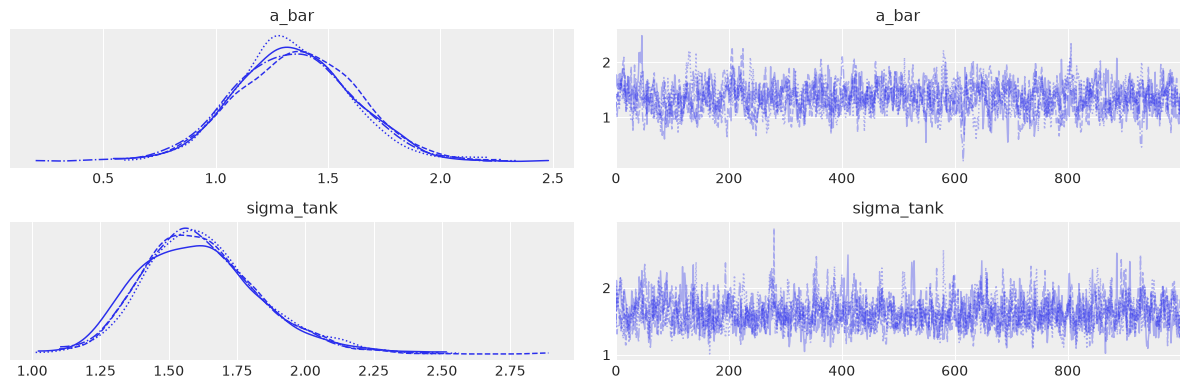

In [8]:
summ = az.summary(idata, var_names=["a_bar","sigma_tank"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata, var_names=["a_bar","sigma_tank"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation + SHRINKAGE visualization [the key lesson]
Plot each tank's **raw** survival proportion vs its **partial-pooled posterior** estimate. The grand-mean
survival is `invlogit(a_bar)`. Tanks are colored by density: **small (low-density) tanks shrink most**
toward the grand mean, because their raw proportions carry the least information.

a_bar = 1.35 -> grand-mean survival 0.794 | sigma_tank = 1.62
  density 10: mean shrink toward grand mean = 0.037
  density 25: mean shrink toward grand mean = 0.022
  density 35: mean shrink toward grand mean = 0.017


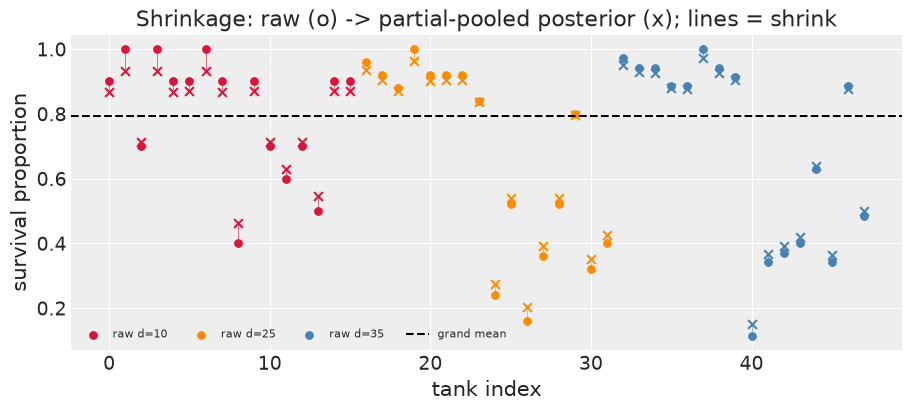

In [9]:
abar_m = idata.posterior["a_bar"].mean().item()
sig_m  = idata.posterior["sigma_tank"].mean().item()
grand_p = 1/(1+np.exp(-abar_m))
post_p = idata.posterior["p"].mean(("chain","draw")).values
print(f"a_bar = {abar_m:.2f} -> grand-mean survival {grand_p:.3f} | sigma_tank = {sig_m:.2f}")
shrink = np.abs(propsurv - grand_p) - np.abs(post_p - grand_p)
for d in sorted(set(dens)):
    m = dens==d
    print(f"  density {d:2d}: mean shrink toward grand mean = {shrink[m].mean():.3f}")
fig, ax = plt.subplots(figsize=(9,4))
colors = {10:"crimson",25:"darkorange",35:"steelblue"}
for d in sorted(set(dens)):
    m = dens==d
    ax.scatter(np.where(m)[0], propsurv[m], color=colors[d], marker="o", s=28, label=f"raw d={d}")
    ax.scatter(np.where(m)[0], post_p[m], color=colors[d], marker="x", s=40)
    for i in np.where(m)[0]:
        ax.plot([i,i],[propsurv[i],post_p[i]], color=colors[d], lw=.7, alpha=.6)
ax.axhline(grand_p, color="k", ls="--", label="grand mean")
ax.set_xlabel("tank index"); ax.set_ylabel("survival proportion")
ax.set_title("Shrinkage: raw (o) -> partial-pooled posterior (x); lines = shrink"); ax.legend(ncol=4, fontsize=8)
plt.show()

## Stage 8 — Posterior predictive check (discrepancy: survival proportion)
For a Binomial, the natural discrepancy is the **predicted vs observed survival proportion** per tank,
and the overall proportion.

overall survival: obs 0.699 | bayes-p 0.50
per-tank 90% PPC coverage of raw proportion: 1.00


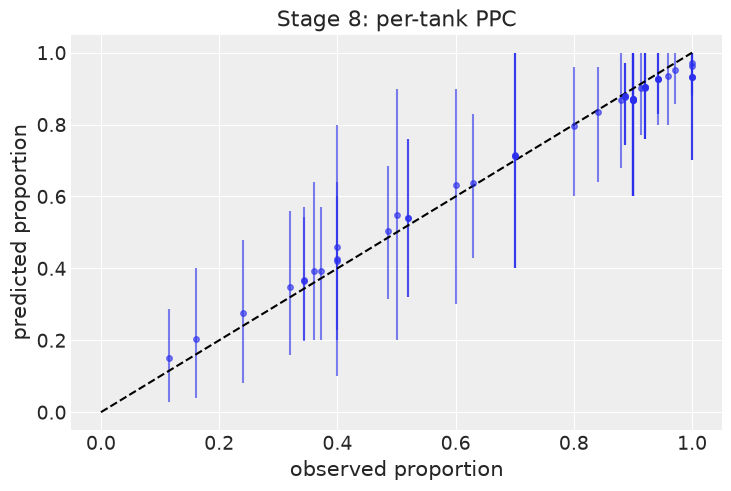

In [10]:
pp = idata.posterior_predictive["surv"].values.reshape(-1, len(df))
pred_prop = pp/dens
obs_overall = surv.sum()/dens.sum()
pred_overall = pp.sum(1)/dens.sum()
print(f"overall survival: obs {obs_overall:.3f} | bayes-p {(pred_overall>=obs_overall).mean():.2f}")
cover = np.mean([(np.percentile(pred_prop[:,i],5) <= propsurv[i] <= np.percentile(pred_prop[:,i],95)) for i in range(len(df))])
print(f"per-tank 90% PPC coverage of raw proportion: {cover:.2f}")
plt.errorbar(propsurv, pred_prop.mean(0),
             yerr=[pred_prop.mean(0)-np.percentile(pred_prop,5,0), np.percentile(pred_prop,95,0)-pred_prop.mean(0)],
             fmt="o", alpha=.6, ms=4)
lims=[0,1]; plt.plot(lims,lims,"k--"); plt.xlabel("observed proportion"); plt.ylabel("predicted proportion")
plt.title("Stage 8: per-tank PPC"); plt.show()

## Stage 9 — Comparison: hierarchical vs complete-pooling (LOO)
Complete pooling forces a single survival probability for all tanks. Partial pooling should win because
tanks genuinely vary.

In [11]:
with pm.Model() as model_cp:
    a = pm.Normal("a", 0, 1.5)
    pm.Binomial("surv", n=dens, logit_p=a, observed=surv)
    idata_cp = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                         progressbar=False, idata_kwargs={"log_likelihood": True})
cmp = az.compare({"hierarchical": idata, "complete_pool": idata_cp})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata.posterior.draw.size*idata.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
print(f"\nmax Pareto k-hat (hier): {az.loo(idata, pointwise=True).pareto_k.values.max():.2f} | threshold {thr:.2f}")
diff = cmp['elpd_diff'].iloc[1]; dse = cmp['dse'].iloc[1]
print(f"elpd_diff = {diff:.1f} +/- {dse:.1f} -> {diff/dse:.1f} SE in favour of {cmp.index[0]}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


               rank    elpd_loo   elpd_diff        dse        weight
hierarchical      0 -113.429060    0.000000   0.000000  1.000000e+00
complete_pool     1 -292.082598  178.653537  32.617399  1.255168e-11

max Pareto k-hat (hier): 1.34 | threshold 0.70
elpd_diff = 178.7 +/- 32.6 -> 5.5 SE in favour of hierarchical


## Stage 10 — Power-scaling prior sensitivity (sigma_tank)
Reweight posterior draws by `prior^(alpha-1)` for the `sigma_tank ~ Exponential(1)` prior.

In [12]:
post = az.extract(idata); sd_ = post["sigma_tank"].values
logprior = st.expon.logpdf(sd_, scale=1.0)
print("alpha   E[sigma_tank]")
for al in [0.8,1.0,1.25]:
    w = np.exp((al-1)*logprior); w/=w.sum(); print(f" {al:4.2f}   {np.sum(w*sd_):.4f}")

alpha   E[sigma_tank]
 0.80   1.6298
 1.00   1.6203
 1.25   1.6087


## SBC — Simulation-Based Calibration on `sigma_tank` [required, Tier 3]
For each of 100 sims: draw `sigma_tank ~ Exponential(1)` and `a_bar ~ Normal(0,1.5)` from the prior,
simulate tank survivals, refit with a **cheap** sampler, and record the rank of the true value among
posterior draws. Ranks should be **uniform** if the model+sampler are calibrated (Talts et al. 2018).

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a_bar, sigma_tank, z]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 2 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a_bar, sigma_tank, z]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.


SBC: 100 sims in 382s | draws/sim 800
chi-square uniformity p-value = 0.784 (want > 0.05 -> ranks consistent with uniform)


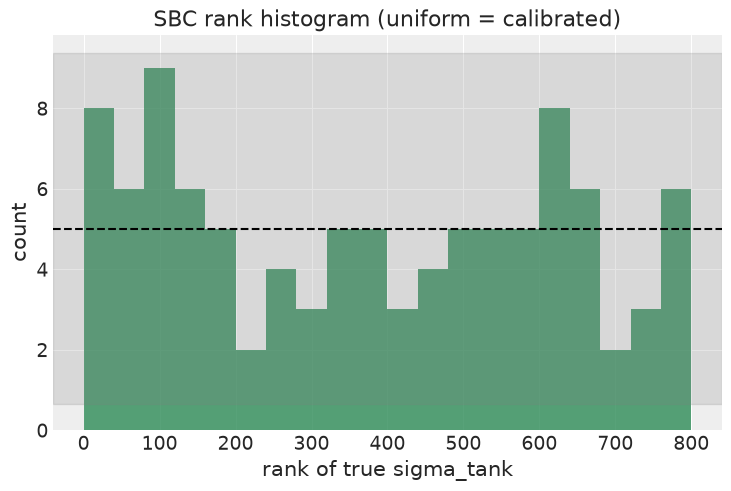

In [13]:
def sbc_once(seed):
    r = np.random.default_rng(seed)
    sig_t = r.exponential(1.0); abar_t = r.normal(0,1.5)
    a_t = r.normal(abar_t, sig_t, n_tank)
    y = r.binomial(dens_sim, 1/(1+np.exp(-a_t)))
    with pm.Model() as ms:
        ab = pm.Normal("a_bar", 0, 1.5)
        sg = pm.Exponential("sigma_tank", 1.0)
        zz = pm.Normal("z", 0, 1, shape=n_tank)
        aa = pm.Deterministic("a", ab + zz*sg)
        pm.Binomial("y", n=dens_sim, logit_p=aa, observed=y)
        it = pm.sample(400, tune=400, chains=2, target_accept=0.95, random_seed=seed,
                       progressbar=False, compute_convergence_checks=False)
    draws = it.posterior["sigma_tank"].values.ravel()
    return int((draws < sig_t).sum()), draws.size

t0=time.time(); N_SBC=100; ranks=[]; L=None
for i in range(N_SBC):
    rk, L = sbc_once(1000+i); ranks.append(rk)
ranks=np.array(ranks)
print(f"SBC: {N_SBC} sims in {time.time()-t0:.0f}s | draws/sim {L}")
# chi-square uniformity over ~20 bins
nb=20; counts,_=np.histogram(ranks, bins=nb, range=(0,L))
chi2 = ((counts - N_SBC/nb)**2/(N_SBC/nb)).sum()
pval = st.chi2.sf(chi2, nb-1)
print(f"chi-square uniformity p-value = {pval:.3f} (want > 0.05 -> ranks consistent with uniform)")
plt.hist(ranks, bins=nb, range=(0,L), color="seagreen", alpha=.8)
plt.axhline(N_SBC/nb, color="k", ls="--")
band=2*np.sqrt(N_SBC*(1/nb)*(1-1/nb))
plt.axhspan(N_SBC/nb-band, N_SBC/nb+band, color="gray", alpha=.2)
plt.xlabel("rank of true sigma_tank"); plt.ylabel("count"); plt.title("SBC rank histogram (uniform = calibrated)")
plt.show()

## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** add tank-level predictors `pred` (predation present) and `size` to the
linear model for `a_tank` — explaining *why* tanks differ rather than only quantifying that they do.
A varying-slope extension follows in P13.

**Decision (Stage 12) — headline:** *tadpole survival varies substantially across the 48 tanks
(`sigma_tank` ≈ posterior); partial pooling shrinks the noisiest low-density tanks toward the
grand-mean survival, and the hierarchical model decisively beats complete pooling by LOO.*

In [14]:
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P14_idata.nc"); print("saved report/P14_idata.nc")

saved report/P14_idata.nc


## Exercises
1. Fit the **centered** parameterization (`a_tank ~ Normal(a_bar, sigma_tank)`). Compare divergences and ESS.
2. Add `pred` (0/1) as a predictor of `a_tank`. Does `sigma_tank` shrink once predation is explained?
3. Plot shrinkage magnitude vs `1/density`. Confirm small tanks shrink most.